# Project FORESIGHT — Exploratory Data Analysis (D2)

**Client:** NorthBay Living | **Deliverable:** D2 — Data-quality & EDA insight memo

This notebook works from the pipeline's output (`data/processed/master_dataset.parquet`),
not the raw extracts — cleaning is handled once, in code, in `src/pipeline.py`, and is
never repeated by hand here (see Definition of Done, brief §4.4).

Sections:
1. Data-quality recap (what was found, how it was handled)
2. Demand distribution & top movers / dead stock
3. Seasonality & trend
4. Promotion effect
5. Outlier detection (IQR & Z-score)
6. Stockout evidence (censored demand)
7. Business insights (plain language)


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_parquet("../data/processed/master_dataset.parquet")
df["date"] = pd.to_datetime(df["date"])
print(f"{len(df):,} rows | {df['sku_id'].nunique()} SKUs | {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


133,500 rows | 200 SKUs | 2024-08-16 to 2026-08-16


,date,sku_id,units_sold,revenue,unit_price,promo_flag,units_sold_corrected_negative,units_sold_imputed,unit_price_imputed,week,...,roll_mean_7,roll_mean_28,roll_std_7,day_of_week,is_weekend,week_of_year,is_promo,has_promo_event,days_since_launch,discount_pct
0,2026-02-17,SKU-0001,7.0,19510.4,2787.2,0,False,False,False,8,...,NaN,NaN,NaN,1,0,8,0,0,0,0.0
1,2026-02-18,SKU-0001,4.0,11148.8,2787.2,0,False,False,False,8,...,NaN,NaN,NaN,2,0,8,0,0,1,0.0
2,2026-02-19,SKU-0001,6.0,16723.2,2787.2,0,False,False,False,8,...,NaN,NaN,NaN,3,0,8,0,0,2,0.0
3,2026-02-20,SKU-0001,6.0,16723.2,2787.2,0,False,False,False,8,...,NaN,NaN,NaN,4,0,8,0,0,3,0.0
4,2026-02-21,SKU-0001,11.0,30659.2,2787.2,0,False,False,False,8,...,NaN,NaN,NaN,5,1,8,0,0,4,0.0


## 1. Data-quality recap

Summary produced automatically by the pipeline (`reports/data_quality_log.json`). Every number below reflects a coded, reproducible cleaning rule — see `src/pipeline.py` docstring for the rationale behind each one.

In [2]:
with open("../reports/data_quality_log.json") as f:
    dq = json.load(f)

print("sku_master: duplicate SKU rows resolved:", dq["clean_sku_master"]["duplicate_sku_ids_resolved"])
print("sku_master: category values after cleaning:", dq["clean_sku_master"]["category_values_after_cleaning"])
print()
print("sales_daily: exact duplicate rows dropped:", dq["clean_sales"]["exact_duplicate_rows_dropped"])
print("sales_daily: negative units_sold clipped to 0:", dq["clean_sales"]["negative_units_sold_clipped_to_zero"])
print("sales_daily: missing units_sold imputed (rolling median):", dq["clean_sales"]["missing_units_sold_imputed_rolling_median"])
print("sales_daily: missing unit_price rows (imputed from list_price):", dq["clean_sales"]["missing_unit_price_rows"])
print()
print("inventory_snapshots: duplicate rows dropped:", dq["clean_inventory"]["exact_duplicate_rows_dropped"])
print("inventory_snapshots: missing lead_time_days imputed:", dq["clean_inventory"]["missing_lead_time_days_imputed"])
print()
print("rows in master dataset with no known inventory position yet:", dq["master_dataset"]["rows_missing_inventory_position"])


sku_master: duplicate SKU rows resolved: 1
sku_master: category values after cleaning: ['Decor', 'Furnishings', 'Small Appliances']

sales_daily: exact duplicate rows dropped: 400
sales_daily: negative units_sold clipped to 0: 29
sales_daily: missing units_sold imputed (rolling median): 667
sales_daily: missing unit_price rows (imputed from list_price): 1335

inventory_snapshots: duplicate rows dropped: 15
inventory_snapshots: missing lead_time_days imputed: 949

rows in master dataset with no known inventory position yet: 619


**Reading this table:** the raw extracts were deliberately imperfect (as the brief warns to expect) — inconsistent category casing (`"FURNISHINGS"` / `" Furnishings "` / `"furnishings"`), a duplicated SKU master row with a conflicting cost, ~400 exact duplicate sales rows, ~1,300 rows missing `unit_price`, ~670 missing `units_sold`, 29 negative `units_sold` values (data-entry errors), mixed date formats (ISO + US `MM/DD/YYYY`), and ~950 missing `lead_time_days` in inventory snapshots. All are handled by coded, documented rules in `src/pipeline.py` — none were edited by hand in a spreadsheet.

## 2. Demand distribution, top movers & dead stock

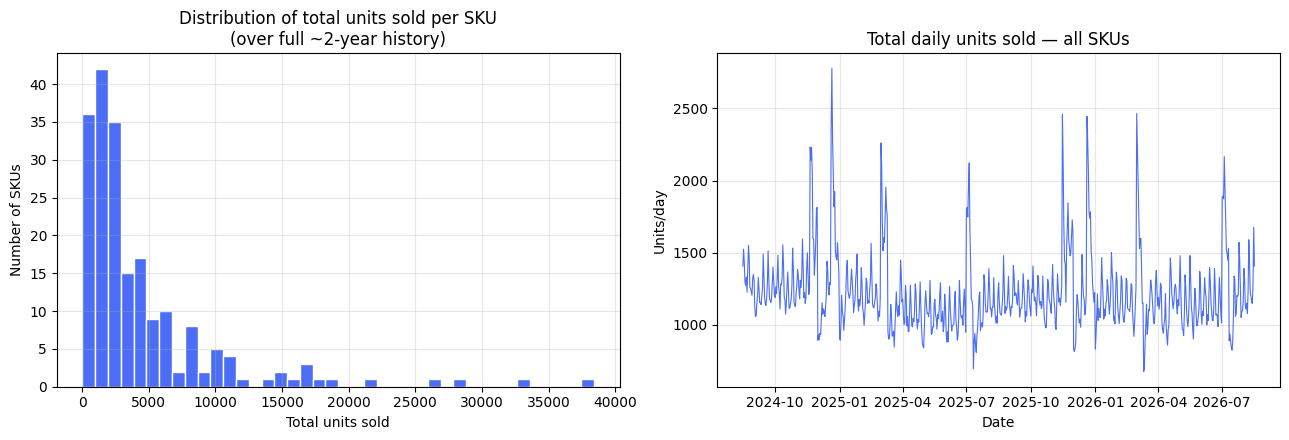

Top 10 SKUs by units sold account for 26.2% of total units.
Bottom decile (20 SKUs) each sold under 685 units total over 2 years — candidates for 'dead stock'.


,total_units,total_revenue,category,subcategory
sku_id,,,,
SKU-0115,38410.568588,5.921938e+08,Furnishings,Storage
SKU-0046,32837.146251,1.089357e+08,Small Appliances,Air Purifiers
SKU-0078,28667.962235,5.362315e+07,Decor,Wall Art
SKU-0005,26118.847358,3.034901e+08,Furnishings,Storage
SKU-0042,22027.140983,7.157371e+07,Small Appliances,Kitchen Appliances
SKU-0174,18862.131675,4.484561e+07,Small Appliances,Fans
SKU-0056,17731.476739,3.702576e+07,Small Appliances,Air Purifiers
SKU-0145,16979.081112,2.824886e+07,Decor,Wall Art
SKU-0162,16782.153027,3.162895e+07,Small Appliances,Heaters


In [3]:
sku_totals = df.groupby("sku_id").agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum"),
    category=("category", "first"),
    subcategory=("subcategory", "first"),
).sort_values("total_units", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(sku_totals["total_units"], bins=40, color="#4C6EF5", edgecolor="white")
axes[0].set_title("Distribution of total units sold per SKU\n(over full ~2-year history)")
axes[0].set_xlabel("Total units sold"); axes[0].set_ylabel("Number of SKUs")

daily_demand = df.groupby("date")["units_sold"].sum()
axes[1].plot(daily_demand.index, daily_demand.values, lw=0.8, color="#4C6EF5")
axes[1].set_title("Total daily units sold — all SKUs")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Units/day")
plt.tight_layout(); plt.show()

n_dead = (sku_totals["total_units"] < sku_totals["total_units"].quantile(0.10)).sum()
print(f"Top 10 SKUs by units sold account for "
      f"{sku_totals['total_units'].head(10).sum() / sku_totals['total_units'].sum():.1%} of total units.")
print(f"Bottom decile ({n_dead} SKUs) each sold under "
      f"{sku_totals['total_units'].quantile(0.10):.0f} units total over 2 years — candidates for 'dead stock'.")
sku_totals.head(10)


In [4]:
print("Bottom 10 movers (dead-stock candidates):")
sku_totals.tail(10)


Bottom 10 movers (dead-stock candidates):


,total_units,total_revenue,category,subcategory
sku_id,,,,
SKU-0197,219.84358,162539.40,Decor,Vases
SKU-0061,195.00000,435122.47,Decor,Lighting
SKU-0143,162.00000,442641.44,Small Appliances,Fans
SKU-0087,135.00000,460445.52,Small Appliances,Fans
SKU-0179,87.00000,265357.12,Small Appliances,Kitchen Appliances
SKU-0049,54.00000,108386.99,Decor,Lighting
SKU-0181,39.00000,200534.24,Small Appliances,Air Purifiers
SKU-0045,36.00000,67735.38,Small Appliances,Air Purifiers
SKU-0082,34.00000,52481.88,Decor,Vases


## 3. Seasonality & trend

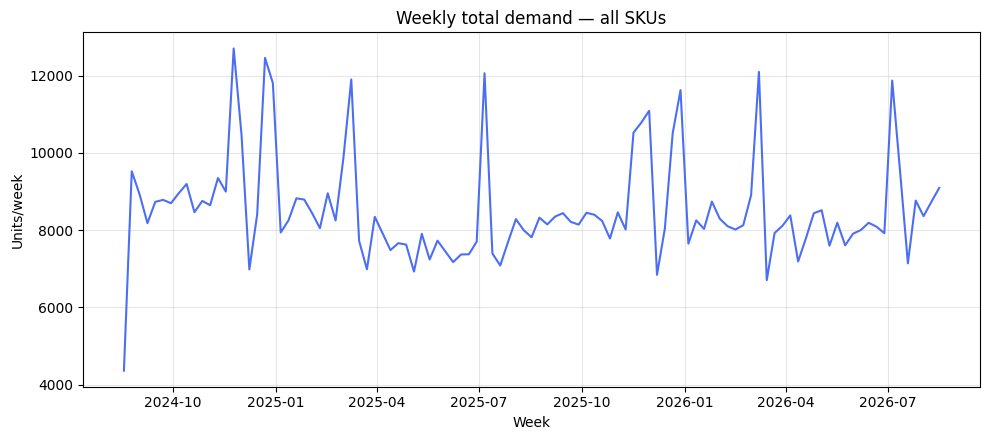

In [5]:
weekly = df.set_index("date").groupby("sku_id").resample("W")["units_sold"].sum().reset_index()
weekly_total = weekly.groupby("date")["units_sold"].sum()

fig, ax = plt.subplots()
ax.plot(weekly_total.index, weekly_total.values, color="#4C6EF5")
ax.set_title("Weekly total demand — all SKUs")
ax.set_xlabel("Week"); ax.set_ylabel("Units/week")
plt.tight_layout(); plt.show()


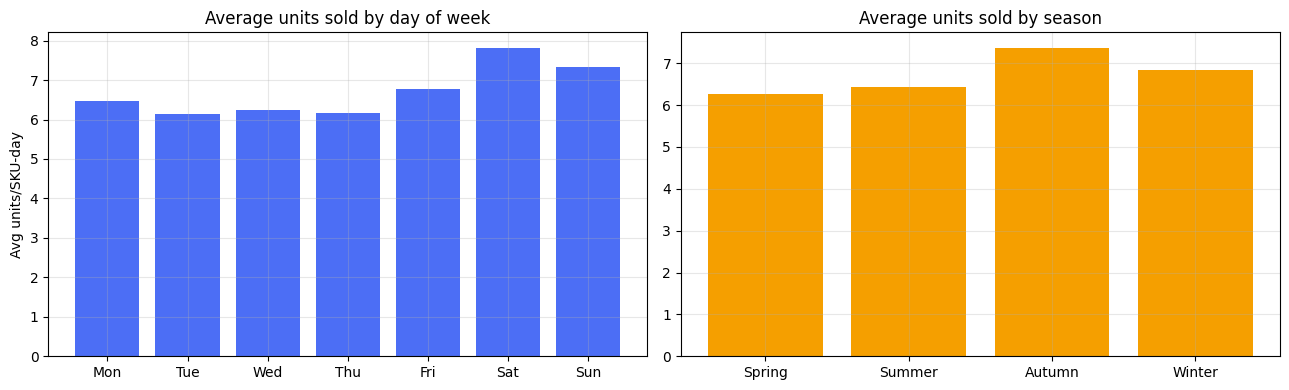

Weekend (Sat/Sun) average is +19.0% vs weekday average.


In [6]:
dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_avg = df.groupby("day_of_week")["units_sold"].mean()

season_avg = df.groupby("season")["units_sold"].mean().reindex(["Spring","Summer","Autumn","Winter"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(dow_names, dow_avg.values, color="#4C6EF5")
axes[0].set_title("Average units sold by day of week")
axes[0].set_ylabel("Avg units/SKU-day")

axes[1].bar(season_avg.index, season_avg.values, color="#F59F00")
axes[1].set_title("Average units sold by season")
plt.tight_layout(); plt.show()

print(f"Weekend (Sat/Sun) average is {dow_avg[[5,6]].mean() / dow_avg[[0,1,2,3,4]].mean() - 1:+.1%} vs weekday average.")


In [7]:
cat_subcat_season = df.groupby(["subcategory"])["units_sold"].mean().sort_values(ascending=False)

# Fans (summer-peaking) vs Heaters (winter-peaking) — check category-specific seasonality
for sub in ["Fans", "Heaters", "Air Purifiers"]:
    if sub in df["subcategory"].unique():
        s = df[df["subcategory"] == sub].groupby("month")["units_sold"].mean()
        peak_month = s.idxmax()
        print(f"{sub}: peak month = {peak_month} (avg {s.max():.1f} units/SKU-day), trough month = {s.idxmin()} (avg {s.min():.1f})")


Fans: peak month = 5 (avg 9.5 units/SKU-day), trough month = 10 (avg 4.6)
Heaters: peak month = 11 (avg 8.4 units/SKU-day), trough month = 5 (avg 2.4)
Air Purifiers: peak month = 11 (avg 12.9 units/SKU-day), trough month = 9 (avg 8.0)


## 4. Promotion effect

In [8]:
promo_effect = df.groupby("is_promo")["units_sold"].mean()
lift = promo_effect[1] / promo_effect[0] - 1
print(f"Average units sold on promo days: {promo_effect[1]:.2f}")
print(f"Average units sold on non-promo days: {promo_effect[0]:.2f}")
print(f"Promotion lift: {lift:+.1%}")

promo_by_cat = df.groupby(["category", "is_promo"])["units_sold"].mean().unstack()
promo_by_cat["lift"] = promo_by_cat[1] / promo_by_cat[0] - 1
promo_by_cat


Average units sold on promo days: 9.50
Average units sold on non-promo days: 6.30
Promotion lift: +50.7%


is_promo,0,1,lift
category,,,
Decor,5.202391,7.736970,0.487195
Furnishings,6.787543,10.489757,0.545442
Small Appliances,7.530057,11.200371,0.487422


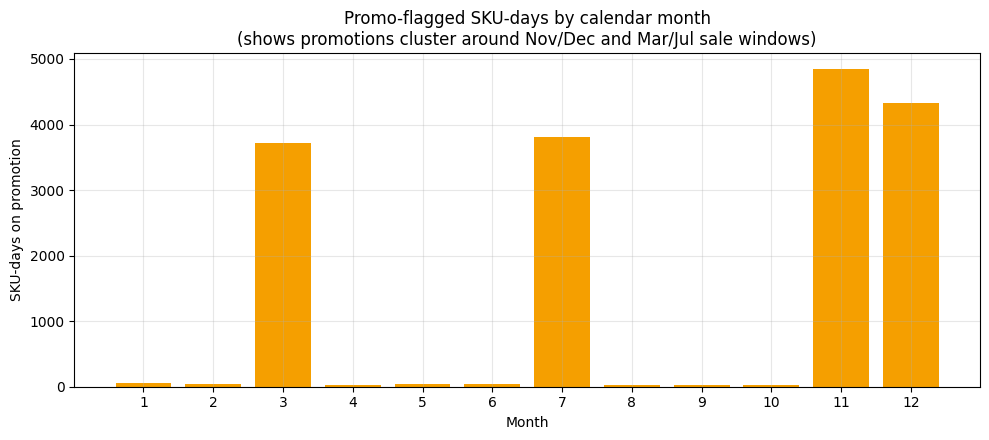

In [9]:
promo_month_counts = df.loc[df["is_promo"] == 1, "date"].dt.month.value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(promo_month_counts.index.astype(str), promo_month_counts.values, color="#F59F00")
ax.set_title("Promo-flagged SKU-days by calendar month\n(shows promotions cluster around Nov/Dec and Mar/Jul sale windows)")
ax.set_xlabel("Month"); ax.set_ylabel("SKU-days on promotion")
plt.tight_layout(); plt.show()


## 5. Outlier detection (IQR & Z-score)

Applied to SKU-day `units_sold` to separate genuine demand spikes (promotions, holidays) from data artefacts. Outliers are **flagged for awareness, not removed** — a promo-driven spike is real demand signal the forecasting model needs to see (via the `is_promo` feature), not noise.

IQR bounds: [-11.0, 21.0] -> 9,100 rows flagged (6.82% of data)
Z-score |z|>3 -> 2,941 rows flagged (2.20% of data)

Share of IQR-flagged rows that are also promo days: 23.5%
Share of IQR-flagged rows that are also holidays:   1.7%


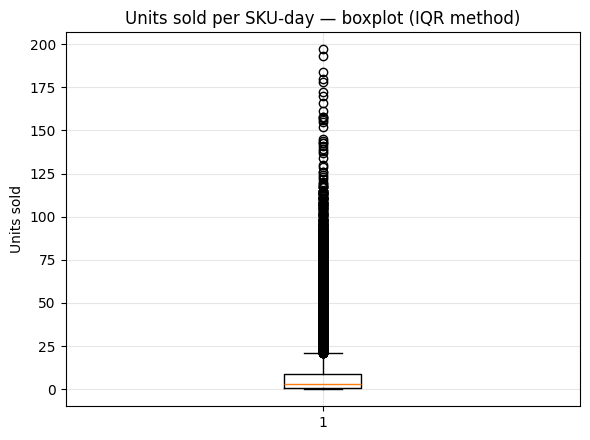

In [10]:
x = df["units_sold"]
q1, q3 = x.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_outliers = df[(x < lower) | (x > upper)]

z = (x - x.mean()) / x.std()
z_outliers = df[z.abs() > 3]

print(f"IQR bounds: [{lower:.1f}, {upper:.1f}] -> {len(iqr_outliers):,} rows flagged ({len(iqr_outliers)/len(df):.2%} of data)")
print(f"Z-score |z|>3 -> {len(z_outliers):,} rows flagged ({len(z_outliers)/len(df):.2%} of data)")
print()
print(f"Share of IQR-flagged rows that are also promo days: {iqr_outliers['is_promo'].mean():.1%}")
print(f"Share of IQR-flagged rows that are also holidays:   {iqr_outliers['is_holiday'].mean():.1%}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot(x.dropna(), vert=True, showfliers=True)
ax.set_title("Units sold per SKU-day — boxplot (IQR method)")
ax.set_ylabel("Units sold")
plt.tight_layout(); plt.show()


**Reading this:** most statistical outliers coincide with promotion or holiday days — they are real, explainable demand, not bad data. This is why the pipeline does not clip or remove them; instead the model is given `is_promo` / `is_holiday` features so it can learn the effect rather than being blinded to it.

## 6. Stockout evidence (censored demand)

When `on_hand_units` hits zero, recorded `units_sold` reflects what the warehouse *could* ship, not what customers actually wanted — true demand is being under-counted for those SKU-days. This directly motivates the risk-scoring layer (D4): a forecast trained naively on sales alone will under-forecast chronically stocked-out SKUs.

82 SKUs spent over 10% of days at zero on-hand stock.
43 SKUs spent over 25% of days at zero on-hand stock — chronic stockout pattern.


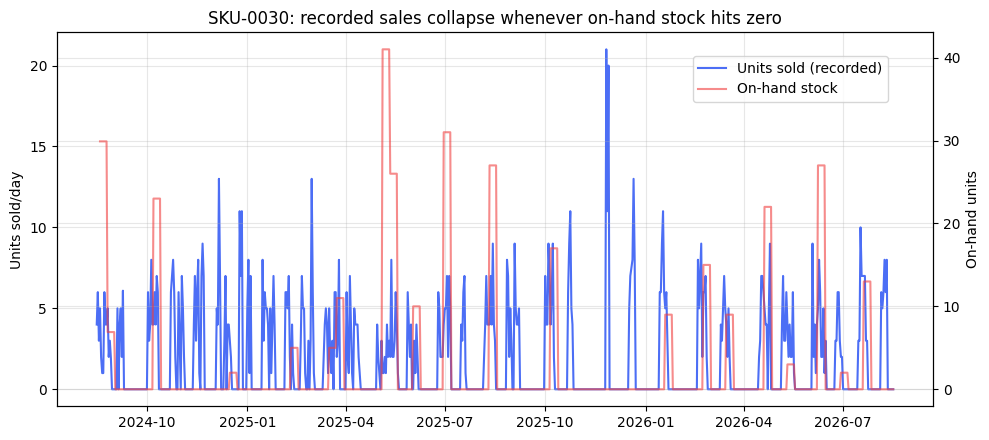

In [11]:
df["was_stocked_out"] = df["on_hand_units"] <= 0
stockout_rate_by_sku = df.groupby("sku_id")["was_stocked_out"].mean().sort_values(ascending=False)

print(f"{(stockout_rate_by_sku > 0.10).sum()} SKUs spent over 10% of days at zero on-hand stock.")
print(f"{(stockout_rate_by_sku > 0.25).sum()} SKUs spent over 25% of days at zero on-hand stock — chronic stockout pattern.")

# Compare average demand in the 7 days *before* a stockout begins vs the day of/after —
# a case a naive model would misread as "demand fell" when really "we ran out".
worst_sku = stockout_rate_by_sku.index[0]
s = df[df["sku_id"] == worst_sku].sort_values("date")
fig, ax = plt.subplots()
ax.plot(s["date"], s["units_sold"], label="Units sold (recorded)", color="#4C6EF5")
ax2 = ax.twinx()
ax2.plot(s["date"], s["on_hand_units"], label="On-hand stock", color="#F03E3E", alpha=0.6)
ax.set_title(f"{worst_sku}: recorded sales collapse whenever on-hand stock hits zero")
ax.set_ylabel("Units sold/day"); ax2.set_ylabel("On-hand units")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout(); plt.show()


## 7. Business insights (plain language)

These are the findings that matter to the Head of Operations, the merchandiser, and Finance — not just charts, but what to do about them.

In [12]:
chronic_stockout_skus = (stockout_rate_by_sku > 0.25).sum()
dead_stock_skus = n_dead
avg_promo_lift = lift

top_locked_capital = (
    df.sort_values("date").groupby("sku_id").tail(1)
    .assign(capital_locked=lambda d: d["on_hand_units"] * d["unit_cost"])
    .sort_values("capital_locked", ascending=False)
)
total_capital_locked = top_locked_capital["capital_locked"].sum()

print("SUMMARY NUMBERS FOR THE MEMO")
print(f"  Chronic-stockout SKUs (>25% of days at zero stock): {chronic_stockout_skus}")
print(f"  Dead-stock candidate SKUs (bottom 10% by units sold): {dead_stock_skus}")
print(f"  Average promotion lift on units sold: {avg_promo_lift:+.1%}")
print(f"  Estimated capital currently tied up in on-hand stock (latest snapshot, at cost): "
      f"Rs {total_capital_locked:,.0f}")


SUMMARY NUMBERS FOR THE MEMO
  Chronic-stockout SKUs (>25% of days at zero stock): 43
  Dead-stock candidate SKUs (bottom 10% by units sold): 20
  Average promotion lift on units sold: +50.7%
  Estimated capital currently tied up in on-hand stock (latest snapshot, at cost): Rs 54,962,882



1. **A meaningful share of the catalog is chronically under-stocked, not just occasionally out of luck.**
   SKUs flagged above spend more than a quarter of all days sitting at zero on-hand stock — meaning
   recorded sales for those products are *understating* true demand every time this happens. Ops is
   likely reordering against demand that already looks artificially low, which can make the problem
   self-reinforcing month over month.

2. **A comparable-sized group of SKUs looks like dead stock — capital sitting on shelves, not moving.**
   The bottom decile of SKUs by total units sold have barely moved in two years of history. Left alone,
   this ties up working capital and, per the brief's own framing, eventually forces margin-eroding
   markdowns rather than a controlled clearance.

3. **Promotions work, but they are concentrated in a few calendar windows (Diwali, year-end, spring,
   monsoon sales)** — the lift measured above is a real, learnable effect, not noise, and the forecast
   model is given explicit promo/holiday features rather than being asked to infer it from raw history
   alone.

4. **Demand has a real weekly and seasonal rhythm** (weekend uplift; category-specific seasonal peaks,
   e.g. heaters in winter, fans in summer) — a naive month-over-month or flat forecast would
   systematically mistime reorders around these swings, which is exactly what the seasonal-naive
   baseline in Section 07 is built to respect.
